In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score, homogeneity_score, completeness_score, v_measure_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('5gym_churn.csv')
print("Размер данных:", df.shape)
df.head()


Размер данных: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
# Проверка пропусков
print("Пропуски:\n", df.isnull().sum())

# Проверка типов
print("\nТипы данных:\n", df.dtypes)

# Описательная статистика
df.describe()


Пропуски:
 gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

Типы данных:
 gender                                 int64
Near_Location                          int64
Partner                                int64
Promo_friends                          int64
Phone                                  int64
Contract_period                        int64
Group_visits                           int64
Age                                    int64
Avg_additional_charges_total         float64
Month_to_e

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [4]:
# Целевая переменная – факт ухода
target = df['Churn']

# Признаки для кластеризации (исключаем целевую)
X = df.drop('Churn', axis=1)

print("Размер X:", X.shape)
print("Распределение Churn:\n", target.value_counts(normalize=True))


Размер X: (4000, 13)
Распределение Churn:
 Churn
0    0.73475
1    0.26525
Name: proportion, dtype: float64


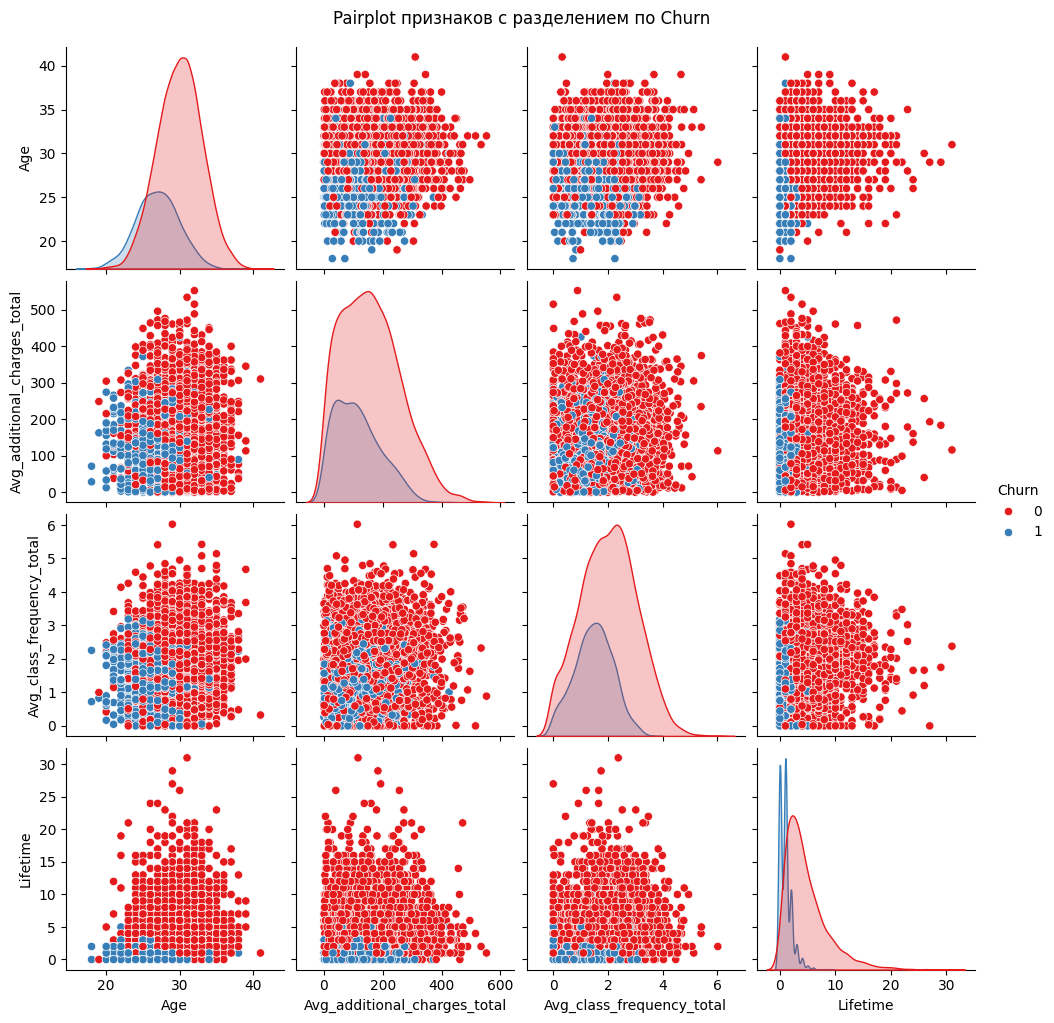

In [5]:
# Для визуализации возьмем несколько числовых признаков
sns.pairplot(df, vars=['Age', 'Avg_additional_charges_total', 
                       'Avg_class_frequency_total', 'Lifetime'],
             hue='Churn', palette='Set1')
plt.suptitle('Pairplot признаков с разделением по Churn', y=1.02)
plt.show()


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Среднее после стандартизации:", X_scaled.mean().round(2))
print("Стандартное отклонение:", X_scaled.std().round(2))


Среднее после стандартизации: gender                               0.0
Near_Location                        0.0
Partner                             -0.0
Promo_friends                       -0.0
Phone                                0.0
Contract_period                     -0.0
Group_visits                        -0.0
Age                                  0.0
Avg_additional_charges_total        -0.0
Month_to_end_contract               -0.0
Lifetime                             0.0
Avg_class_frequency_total           -0.0
Avg_class_frequency_current_month    0.0
dtype: float64
Стандартное отклонение: gender                               1.0
Near_Location                        1.0
Partner                              1.0
Promo_friends                        1.0
Phone                                1.0
Contract_period                      1.0
Group_visits                         1.0
Age                                  1.0
Avg_additional_charges_total         1.0
Month_to_end_contract        

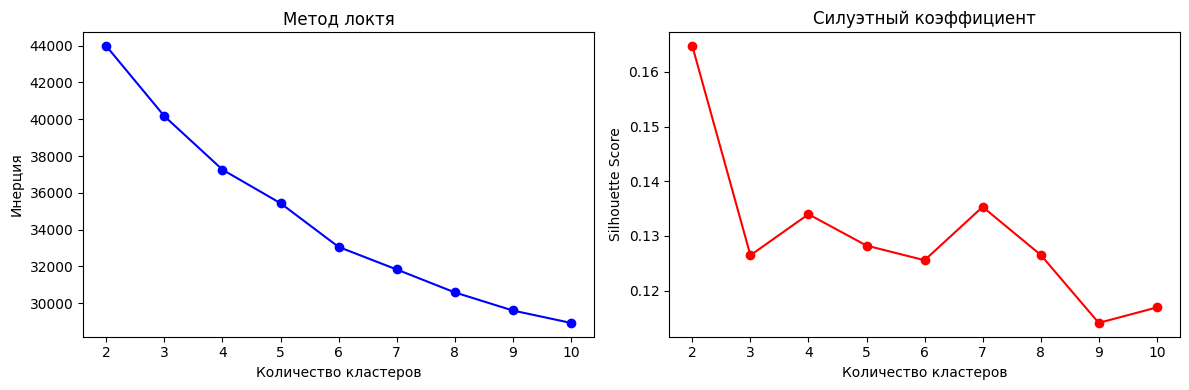

Оптимальное количество кластеров по графику: 3


In [7]:
# Метод локтя
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Количество кластеров')
ax1.set_ylabel('Инерция')
ax1.set_title('Метод локтя')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Количество кластеров')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Силуэтный коэффициент')

plt.tight_layout()
plt.show()

optimal_k = 3
print(f"Оптимальное количество кластеров по графику: {optimal_k}")


In [8]:
# Обучение с оптимальным k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)

# Средние показатели по кластерам
cluster_stats = df.groupby('Cluster_KMeans').mean().round(2)
cluster_stats


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
Cluster_KMeans,,,,,,,,,,,,,,
0,0.49,0.76,0.38,0.19,0.91,1.88,0.29,28.06,127.95,1.79,2.23,1.22,0.97,0.56
1,0.51,0.94,0.78,0.57,0.90,10.70,0.54,29.89,161.95,9.79,4.68,1.96,1.95,0.03
2,0.55,0.87,0.34,0.22,0.90,2.45,0.45,30.04,158.36,2.28,4.85,2.72,2.71,0.09


In [9]:
labels_kmeans = df['Cluster_KMeans']
true_labels = target

# Вычисление метрик
metrics_kmeans = {
    'ARI': adjusted_rand_score(true_labels, labels_kmeans),
    'AMI': adjusted_mutual_info_score(true_labels, labels_kmeans),
    'Homogeneity': homogeneity_score(true_labels, labels_kmeans),
    'Completeness': completeness_score(true_labels, labels_kmeans),
    'V-measure': v_measure_score(true_labels, labels_kmeans),
    'Silhouette': silhouette_score(X_scaled, labels_kmeans)
}

metrics_df = pd.DataFrame([metrics_kmeans], index=['KMeans'])
metrics_df.round(4)


,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
KMeans,0.1193,0.2058,0.2964,0.158,0.2061,0.1265


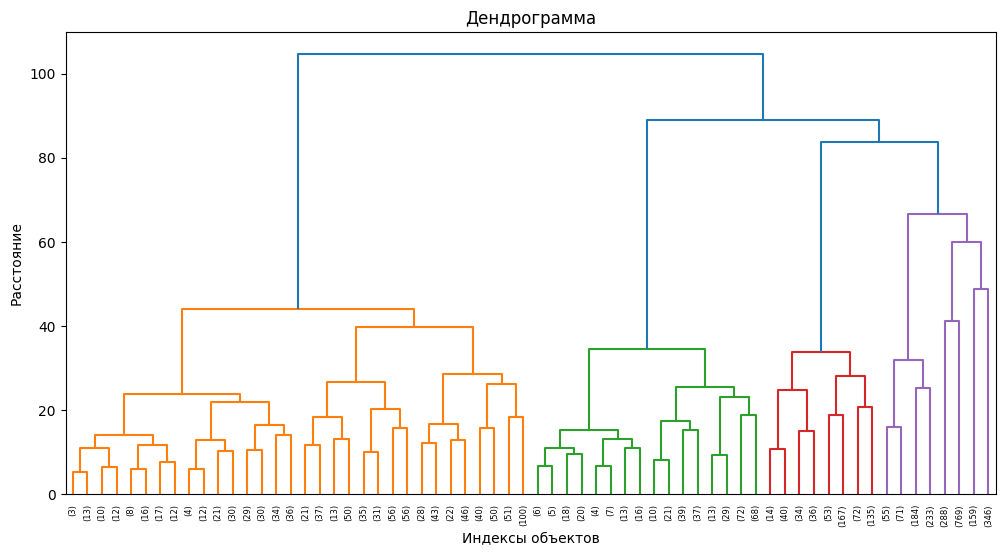

In [10]:
# Построение дендрограммы
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Дендрограмма')
plt.xlabel('Индексы объектов')
plt.ylabel('Расстояние')
plt.show()


In [11]:
# Агломеративная кластеризация
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Cluster_Agg'] = agg.fit_predict(X_scaled)

# Средние по кластерам
agg_stats = df.groupby('Cluster_Agg').mean().round(2)
print(agg_stats)

# Метрики
labels_agg = df['Cluster_Agg']
metrics_agg = {
    'ARI': adjusted_rand_score(true_labels, labels_agg),
    'AMI': adjusted_mutual_info_score(true_labels, labels_agg),
    'Homogeneity': homogeneity_score(true_labels, labels_agg),
    'Completeness': completeness_score(true_labels, labels_agg),
    'V-measure': v_measure_score(true_labels, labels_agg),
    'Silhouette': silhouette_score(X_scaled, labels_agg)
}

metrics_df = pd.concat([metrics_df, pd.DataFrame([metrics_agg], index=['Agglomerative'])])
metrics_df.round(4)


             gender  Near_Location  Partner  Promo_friends  Phone  \
Cluster_Agg                                                         
0              0.53           0.79     0.42           0.25    1.0   
1              0.46           1.00     0.68           0.48    1.0   
2              0.52           0.86     0.47           0.31    0.0   

             Contract_period  Group_visits    Age  \
Cluster_Agg                                         
0                       2.49          0.38  28.97   
1                      10.73          0.51  29.72   
2                       4.64          0.43  29.28   

             Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
Cluster_Agg                                                                  
0                                  141.26                   2.32      3.52   
1                                  164.26                   9.82      4.29   
2                                  142.59                   4.34      3.71  

,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
KMeans,0.1193,0.2058,0.2964,0.158,0.2061,0.1265
Agglomerative,-0.0384,0.0778,0.0956,0.066,0.0781,0.1428
